In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("powerplant_data.csv")

In [3]:
df.shape

(9568, 5)

In [4]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [5]:
# AT => Temperature
# V => Vaccume
# AP => Pressure	 
# RH => Humidity

# PE => Produced Energy

In [6]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [7]:
X = df.drop("PE", axis=1)
y = df["PE"]

In [8]:
# Split data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Tensors 

In [10]:
import torch
import torch.nn as nn

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1,1)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1,1)

# Datasets and DataLoaders

In [11]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [12]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

# Build ANN Model (Deep Learning)

In [13]:
# Define Model
class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()
        
        self.model = nn.Sequential(
            # 1st hidden layer
            nn.Linear(X_train.shape[1], 6),
            nn.ReLU(),
    
            # 2nd hidden layer
            nn.Linear(6, 6),
            nn.ReLU(),
    
            # Output layer
            nn.Linear(6,1)
        )

    def forward(self, x):
        return self.model(x)
    

In [14]:
import torch.optim as optim

model = ANN()

# Loss, optimizer
crietrion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

# Train ANN

In [15]:
train_losses = []
valid_losses = []

best_val_loss = float("inf")

epochs = 100

for epoch in range(epochs):
    model.train() # Shifting to training mode

    running_loss = 0.0 # total trainig loss for 1 epoch
    
    for xb, yb in train_loader:
        # xb -> features of 1 batch
        # yb -> labels of 1 batch
        optimizer.zero_grad()
        
        outputs = model(xb) # forward prop..  predicted outputs for this batch
        loss = crietrion(outputs, yb) # compute loss
        loss.backward() # backward prop.. compute gradients
        optimizer.step() # params update

        running_loss += loss.item() # Loss is a tensor => py float 

    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)


    # Validation 
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad(): # no gradients compute
        for xb, yb in test_loader:
            outputs = model(xb)
            loss = crietrion(outputs, yb) 
            running_val_loss += loss.item()
    
    epoch_vaidation_loss = running_val_loss / len(test_loader)
    valid_losses.append(epoch_vaidation_loss)

    print(f"epoch {epoch+1}/{epochs} ==> train loss = {epoch_train_loss} & validation loss = {epoch_vaidation_loss}")

    if epoch_vaidation_loss < best_val_loss:
        best_val_loss = epoch_vaidation_loss
        torch.save(model.state_dict(), "best_model.pt") # .pt or .pth
        

epoch 1/100 ==> train loss = 206039.787109375 & validation loss = 204502.553125
epoch 2/100 ==> train loss = 197730.12701822916 & validation loss = 184498.91927083334
epoch 3/100 ==> train loss = 158018.2755533854 & validation loss = 125288.76744791666
epoch 4/100 ==> train loss = 90344.94368489583 & validation loss = 58171.4361328125
epoch 5/100 ==> train loss = 38161.140356445314 & validation loss = 24993.04580078125
epoch 6/100 ==> train loss = 19123.354345703126 & validation loss = 16076.268766276042
epoch 7/100 ==> train loss = 13585.802516682943 & validation loss = 12146.703165690104
epoch 8/100 ==> train loss = 10288.621095784505 & validation loss = 9096.094677734374
epoch 9/100 ==> train loss = 7589.787056477865 & validation loss = 6542.723409016927
epoch 10/100 ==> train loss = 5370.909947713216 & validation loss = 4547.870874023438
epoch 11/100 ==> train loss = 3682.170325724284 & validation loss = 3066.8052225748697
epoch 12/100 ==> train loss = 2458.7701212565103 & validati

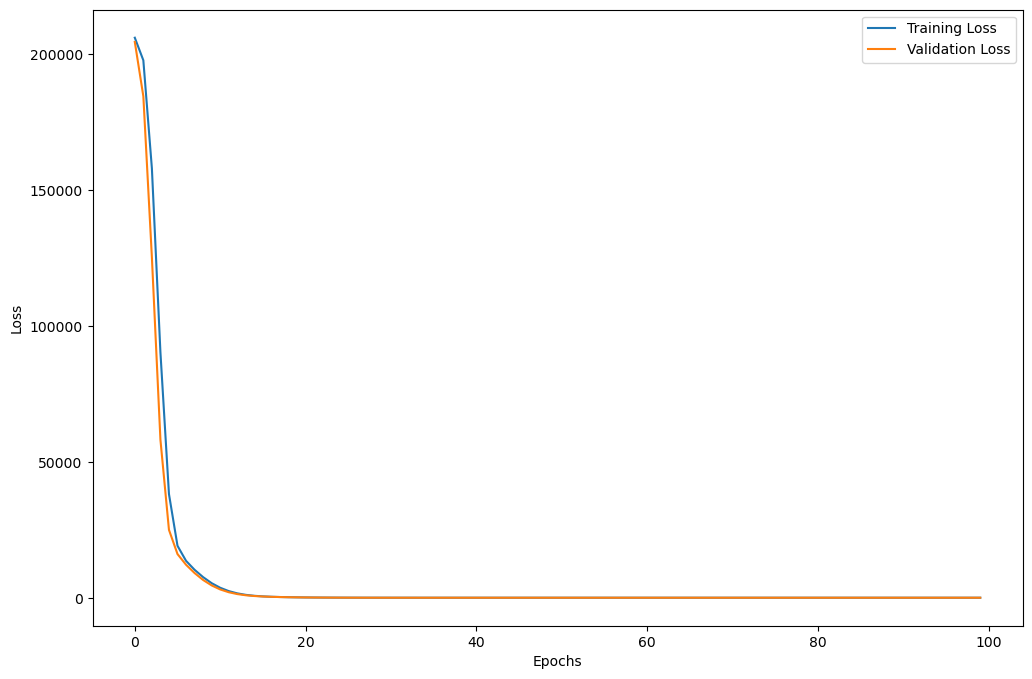

In [18]:
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({
    "Training Loss": train_losses,
    "Validation Loss": valid_losses
})

plt.figure(figsize=(12,8))

plt.plot(loss_df["Training Loss"], label="Training Loss")
plt.plot(loss_df["Validation Loss"], label="Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend()
plt.show()

# Loading the best model

In [19]:
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

# Evaluate Model

In [23]:
model.eval()
with torch.no_grad():
    train_preds = model(X_train_tensor)
    test_preds = model(X_test_tensor)

    train_mse_loss = crietrion(train_preds, y_train_tensor)
    test_mse_loss = crietrion(test_preds, y_test_tensor)

print("Training MSE: ",train_mse_loss.item())
print("Test MSE: ",test_mse_loss.item())

Training MSE:  20.772016525268555
Test MSE:  18.989761352539062


In [24]:
from sklearn.metrics import r2_score

print("R2 score: ",r2_score(y_test, test_preds))

R2 score:  0.9336356856880247


In [27]:
predicted_df = pd.DataFrame(test_preds.numpy(), columns=["Predicted Values"]) 
actual_df = pd.DataFrame(y_test.values, columns=["Actual Values"]) 

pd.concat([predicted_df, actual_df], axis=1)

,Predicted Values,Actual Values
0,435.469757,433.27
1,436.680511,438.16
2,461.325500,458.42
3,475.952057,480.82
4,435.590729,441.41
...,...,...
1909,451.153900,456.70
1910,431.643097,438.04
1911,467.488037,467.80
1912,431.019440,437.14
